In this notebook, we compare the Večeř PDE and Monte Carlo pricing methods for Asian options.

From our work with volatility of oil prices, we know 0.4 is a reasonable value for volatility.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import scipy
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

from tqdm import trange

In [2]:
# Taken from `Vecer PDE for Asian Options.ipynb`

def q_continuous_tau(tau, r, T):
    """
    Computes q as a function of tau = T - t.

    Parameters
    ----------
    tau : float
        Forward time variable tau = T - t.
    r : float
        Risk-free interest rate.
    T : float
        Maturity.

    Returns
    -------
    float
        The value q(tau) = (1 - exp(-r tau)) / (r T),
        with the correct limiting formula when r is close to zero.
    """
    if abs(r) < 1e-12:
        return tau / T
    return (1.0 - np.exp(-r * tau)) / (r * T)

def price_asian_vecer_fixed_strike(
    S0,
    K,
    r,
    sigma,
    T,
    option_type="call",
    z_min=-1.5,
    z_max=1.5,
    Nz=801,
    Nt=1000,
    return_grid=False
):
    """
    Prices a continuously sampled fixed-strike Asian option using the one-dimensional Věčer PDE.

    Parameters
    ----------
    S0 : float
        Initial stock price.
    K : float
        Strike price.
    r : float
        Continuously compounded risk-free rate.
    sigma : float
        Volatility.
    T : float
        Maturity in years.
    option_type : str
        Either "call" or "put".
    z_min : float
        Lower bound of the spatial z-grid.
    z_max : float
        Upper bound of the spatial z-grid.
    Nz : int
        Number of z-grid points.
    Nt : int
        Number of time steps.
    return_grid : bool
        If True, return the full z-grid and final PDE solution.

    Returns
    -------
    price : float
        The Asian option price.
    z0 : float
        The transformed initial state.
    z : numpy.ndarray
        The z-grid, returned only if return_grid=True.
    v : numpy.ndarray
        The PDE solution at tau=T, returned only if return_grid=True.
    """

    # ------------------------------------------------------------
    # 1. Build the spatial grid in z.
    # ------------------------------------------------------------
    z = np.linspace(z_min, z_max, Nz)
    dz = z[1] - z[0]
    dt = T / Nt

    # ------------------------------------------------------------
    # 2. Initial condition in tau.
    # ------------------------------------------------------------
    option_type = option_type.lower()

    if option_type == "call":
        v = np.maximum(z, 0.0)
    elif option_type == "put":
        v = np.maximum(-z, 0.0)
    else:
        raise ValueError("option_type must be either 'call' or 'put'.")

    # ------------------------------------------------------------
    # 3. Boundary conditions.
    #
    # For a call:
    #   as z -> -infinity, v -> 0
    #   as z -> +infinity, v ~ z
    #
    # For a put:
    #   as z -> -infinity, v ~ -z
    #   as z -> +infinity, v -> 0
    # ------------------------------------------------------------
    if option_type == "call":
        left_boundary = 0.0
        right_boundary = z_max
    else:
        left_boundary = -z_min
        right_boundary = 0.0

    # ------------------------------------------------------------
    # 4. Time stepping.
    #
    # At each step we solve:
    #
    #   v_new - dt * a * Dzz(v_new) = v_old
    # ------------------------------------------------------------
    for n in range(Nt):
        tau_next = (n + 1) * dt

        q = q_continuous_tau(tau_next, r, T)

        # Interior grid points only.
        z_interior = z[1:-1]

        # Diffusion coefficient a(tau,z).
        a = 0.5 * sigma**2 * (q - z_interior)**2

        # lambda_j = dt * a_j / dz^2
        lam = dt * a / dz**2

        # Tridiagonal matrix:
        #
        # -lam_j * v_{j-1}^{new}
        # + (1 + 2 lam_j) * v_j^{new}
        # - lam_j * v_{j+1}^{new}
        # = v_j^{old}
        lower_diagonal = -lam[1:]
        main_diagonal = 1.0 + 2.0 * lam
        upper_diagonal = -lam[:-1]

        A = diags(
            diagonals=[lower_diagonal, main_diagonal, upper_diagonal],
            offsets=[-1, 0, 1],
            format="csc"
        )

        rhs = v[1:-1].copy()

        # Add boundary-condition contributions.
        rhs[0] += lam[0] * left_boundary
        rhs[-1] += lam[-1] * right_boundary

        # Solve for the new interior values.
        v_new_interior = spsolve(A, rhs)

        # Reconstruct the full solution including boundaries.
        v[0] = left_boundary
        v[-1] = right_boundary
        v[1:-1] = v_new_interior

    # ------------------------------------------------------------
    # 5. Compute the initial transformed state z0.
    #
    # At t=0 it holds that
    #
    # z0 = q(0) - exp(-rT) K/S0.
    #
    # In tau variables, q(0) means q_tau(T).
    # ------------------------------------------------------------
    q0 = q_continuous_tau(T, r, T)
    z0 = q0 - np.exp(-r * T) * K / S0

    # Interpolate the PDE solution at z0.
    v_at_z0 = np.interp(z0, z, v)

    # Recover the actual option price.
    price = S0 * v_at_z0

    if return_grid:
        return price, z0, z, v

    return price

In [3]:
# taken from `Asian_Options.ipynb`
def GBM_paths(S0, sigma, t, r, mu, n_sims, n_steps):
    """Simulates stock paths as geometric Brownian Motions
    Inputs:
    S0 (float): Underlying stock price at time 0
    sigma (float): Yearly volatility
    t (float): Time to expiration (years)
    r (float): Risk-free interest rate
    mu (float): Drift of log-returns
    n_sims (int): Number of simulated paths
    n_steps (int): Number of steps in each simulated path, each step interval has length t/n_steps
    
    Return (np.array): Array of stock paths
    """
    
    dt = t/n_steps
    noise = np.random.normal(loc = 0, scale = 1, size = (n_sims, n_steps))
    log_returns = (mu+r-sigma**2*(0.5))*dt + sigma*np.sqrt(dt)*noise
    exponent = np.cumsum(log_returns, axis = 1)
    paths = S0*np.exp(exponent)
    paths_with_start = np.insert(paths, 0, S0, axis = 1)

    return paths_with_start

def asian_call_price_mc(S0, K,sigma,t,r,n_sims = 1000,n_steps = 2520): #Function that returns a 1x2 array. 
                                                                        #One entry is the Monte-Carlo estimate of the price of the Asian Call.
                                                                        #The other entry is the standard error of the estimate. 
    stock_paths = GBM_paths(S0, sigma, t, r, 0, n_sims, n_steps)
    
    avg_val_of_stocks = np.mean(stock_paths, axis = 1) #mean of each stock path
    
    payoffs = np.maximum(avg_val_of_stocks - K, 0) # Call payoffs
    
    prices = np.exp(-r*t) * payoffs #discounting to time 0
    
    return [np.average(prices), np.std(prices)/np.sqrt(n_sims)] # Actual estimate is zero-th entry of the resulting array
                                                                # The standard error of the estimate is the first entry 



In [4]:
# Taken from `Volatility.ipynb`
def theoretical_payout(K, r, T, sigma, Type = 'call', Greeks = False):
    """
Prices a European option using the Black-Scholes equation, optinally returning the Greeks as well.
Note: This is normalized so that S_0=1. I.e. the return value and K are in terms of returns. This also affects the Greeks

Parameters
----------
K: float
    Strike price
r: float
    Risk-free rate (continuously compounded)
T: float
    Time to contract maturity
sigma: float
    Volatility
Type: str
    Type of contract; either 'call' or 'put'
Greeks: bool
    Whether or not to also return a dict of the Greeks for the contract
"""
    assert Type in ['call', 'put'], "Type of contract must either be a call or a put"

    # d_1 and d_2 are called dplus and dminus in the code respectively
    if (sigma*np.sqrt(T)) == 0:
        print('first')
        print(K, r, T, sigma)
    if K == 0:
        print('second')
        print(K, r, T, sigma)
    dplus  = 1/(sigma*np.sqrt(T))*(np.log(1/K)+(r+(sigma**2)/2)*T)
    dminus = 1/(sigma*np.sqrt(T))*(np.log(1/K)+(r-(sigma**2)/2)*T)
    
    if Type == 'call':
        value = scipy.stats.norm.cdf(dplus) - K*np.exp(-r*T)*scipy.stats.norm.cdf(dminus)
    else: # This is the value for a put
        value = -scipy.stats.norm.cdf(-dplus) + K*np.exp(-r*T)*scipy.stats.norm.cdf(-dminus)

    if not Greeks:
        return value

    greeks = {
        'delta': scipy.stats.norm.cdf(dplus) if Type == 'call' else scipy.stats.norm.cdf(dplus) - 1,
        'gamma': scipy.stats.norm.pdf(dplus) / (sigma * np.sqrt(T)),
        'vega': scipy.stats.norm.pdf(dplus) * np.sqrt(T),
        'theta': -scipy.stats.norm.pdf(dplus) * sigma / (2*np.sqrt(T)) - r * K * np.exp(-r*T) * scipy.stats.norm.cdf(dminus) if Type == 'call' else \
                 -scipy.stats.norm.pdf(dplus) * sigma / (2*np.sqrt(T)) + r * K * np.exp(-r*T) * scipy.stats.norm.cdf(-dminus),
        'rho': K * T * np.exp(-r*T) * scipy.stats.norm.cdf(dminus) if Type == 'call' else \
               -K * T * np.exp(-r*T) * scipy.stats.norm.cdf(-dminus)
    }

    return value, greeks

# Comparison of different methods of evaluating asian options

In [42]:
S0 = 250
sigma = 0.4
T = 1
K = 240
r = 0.035

In [44]:
import time

time_1 = time.perf_counter()
mean, SE = asian_call_price_mc(S0, K, sigma, T, r, n_sims = 10000)
time_2 = time.perf_counter()
mean_PDE = price_asian_vecer_fixed_strike(S0, K, r, sigma, T)
time_3 = time.perf_counter()
print(f'Monte Carlo Method: {mean}')
print(f'95% Confidence interval: ({mean-2*SE}, {mean+2*SE})')
print(f'Computation time: {time_2-time_1}')

print(f'Vecer Method: {price_asian_vecer_fixed_strike(S0, K, r, sigma, T)}')
print(f'Computation time: {time_3-time_2}')

Monte Carlo Method: 29.2332065337329
95% Confidence interval: (28.361733673319915, 30.104679394145887)
Computation time: 1.0109301999909803
Vecer Method: 29.550367136749376
Computation time: 0.3678919000085443


Both methods give similar values, as expected.

# Comparison with European option prices

A crude estimate tell us the average price of an asset should be roughly $\frac{S_0+S_T}{2}$. From this, we can should naively expect an asian option to be priced at about half of the corresponding European option

In [7]:
K = np.arange(0.25, 1.75, 0.05)
sigma = np.arange(0.05, 1, 0.05)
KK, Sigma = np.meshgrid(K, sigma)

asian_price = np.zeros_like(KK)
european_price = np.zeros_like(KK)

indices = [index for index, _ in np.ndenumerate(KK)]

for i in trange(len(indices)):
    index = indices[i]
    european_price[index] = theoretical_payout(KK[index], r, 1, Sigma[index])
    asian_price[index] = price_asian_vecer_fixed_strike(1, KK[index], r, Sigma[index], 1)

100%|████████████████████████████████████████████████████████████████████████████████| 570/570 [02:56<00:00,  3.23it/s]


In [26]:
%%javascript
IPython.OutputArea.prototype._should_scroll = function(lines) {
    return false;
}

<IPython.core.display.Javascript object>

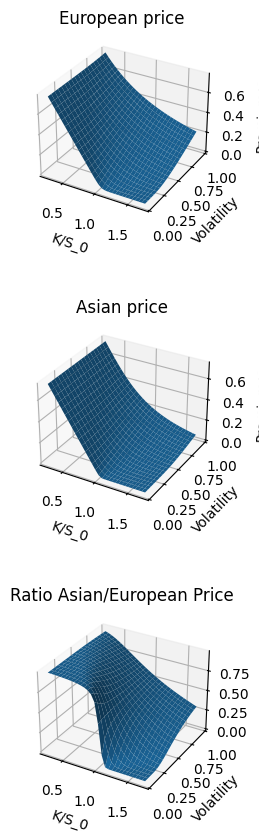

In [37]:
fig, axs = plt.subplots(3, 1, subplot_kw={'projection': '3d'}, figsize = (10, 10))
plt.subplots_adjust(hspace=0.5)

axs[0].plot_surface(KK, Sigma, european_price)
axs[0].set_title('European price')

axs[1].plot_surface(KK, Sigma, asian_price)
axs[1].set_title('Asian price')

axs[2].plot_surface(KK, Sigma, asian_price / european_price)
axs[2].set_title('Ratio Asian/European Price')

for ax in axs:
    ax.set_xlabel('K/S_0')
    ax.set_ylabel('Volatility')

axs[0].set_zlabel('Premium/S_0')
axs[1].set_zlabel('Premium/S_0')

plt.show()

# Comparison of Delta
We see Asian prices are consistently smaller than European options, as our intuition would expect. We can also try comparing delta because it should also be smaller.

Because of the computational difficulty of computing delta, we do this only for a few values. From our historical data, we know about 0.4 is a realistic choice of volatility for crude oil.

In [33]:
## Pathwise approach

# In this approach, assume that the running average is calculated at a fixed number of dates. 

# Interchanging the expectation and the derivative, when we are at time t, the derivative (w.r.t. S_t) of the payoff becomes 
# e^(-r(T-t)) * (1/n_steps) * \sum_i (S_i/S_t) if the payoff > K. Otherwise the derivative vanishes. The sum runs over i occuring AFTER t (inclusive). 
# So we need to estimate the expected value of this expression.

def asian_call_delta_pw(
    S_t, # Current Stock Price
    K, # Strike
    Avg_t, #Current Running Average
    t, # Current time
    sigma, T, r, # Volatility, Time to Exp, Risk-free interest rate
    n_sims, # Number of simulations
    n_steps = 2520
):
    steps_after_t = int(np.ceil(((T-t)/T) * n_steps)) # Number of steps before the current time t
    
    steps_before_t = int(np.floor((t/T) * n_steps)) # Number of steps after the current time t
    
    paths_starting_at_t = GBM_paths(S_t, sigma, T-t, r, 0, n_sims, steps_after_t) # Simulated paths starting at time t

    total_avg = (steps_before_t * Avg_t + np.sum(paths_starting_at_t,axis=1))/(n_steps) # Final averages of the paths at expiration

    avg_minus_strike = total_avg - K # Final averages minus the strike price
    
    payoffs = np.maximum(avg_minus_strike,0) # The payoffs of the paths at expiration
    
    ratios_of_stock_to_current = paths_starting_at_t / S_t # Terms of the sum appearing in the derivative of the payoff expression

    sum_of_ratios = np.sum(ratios_of_stock_to_current, axis = 1) # Adding the terms of the sum 
    
    deriv_of_payoffs = np.exp(-r*(T-t)) * np.sign(payoffs) * np.exp(-r*(T-t)) * sum_of_ratios / n_steps # Calculating the derivative of the payoff

    return [np.average(deriv_of_payoffs), np.std(deriv_of_payoffs)/np.sqrt(n_sims)] # Array that has the Monte Carlo estimate of the Delta,
                                                                                    # the expected value of the derivative of the payoff,
                                                                                    # along with the standard error of the estimate.


In [38]:
print('1 year call options with sigma=0.4, r=0.04 and underlying value 1')
for K in [0.8, 0.9, 1, 1.1, 1.2]:
    print(f'K = {K}')
    print(f'-- Asian option price: {price_asian_vecer_fixed_strike(1, K, 0.04, 0.4, 1,):}')
    european_value, european_greeks = theoretical_payout(K, 0.04, T, 0.4, Greeks = True)
    print(f'-- European option price: {european_value}')
    asian_mean, asian_se = asian_call_delta_pw(1, K, 0, 0, 0.4, 1, 0.04, 10000)
    print(f'-- Average asian delta: {asian_mean}')
    print(f'-- Asian delta 95% CI: {asian_mean-2*asian_se, asian_mean+2*asian_se}')
    print(f'-- European delta: {european_greeks['delta']}')

1 year call options with sigma=0.4, r=0.04 and underlying value 1
K = 0.8
-- Asian option price: 0.2257208506240267
-- European option price: 0.28455624734602614
-- Average asian delta: 0.8285361922873501
-- Asian delta 95% CI: (np.float64(0.8201585939840523), np.float64(0.8369137905906479))
-- European delta: 0.8045148033278835
K = 0.9
-- Asian option price: 0.15408906738787032
-- European option price: 0.22494528713539275
-- Average asian delta: 0.701055504800035
-- Asian delta 95% CI: (np.float64(0.6906561416939999), np.float64(0.71145486790607))
-- European delta: 0.7134191702230135
K = 1
-- Asian option price: 0.09946376198983843
-- European option price: 0.17578286805283777
-- Average asian delta: 0.5363752467463674
-- Asian delta 95% CI: (np.float64(0.5248982738675978), np.float64(0.547852219625137))
-- European delta: 0.6179114221889527
K = 1.1
-- Asian option price: 0.06124067909129411
-- European option price: 0.13612753842408887
-- Average asian delta: 0.3970575171968918
-- 